<h3>Undersampling for regression - case diamonds data</h3>

**TODO: rewrite comments and clean up unnecessary code sections**

In [1]:
# imports, load data etc. here

# by default, we'll use Python 3.12
# many of the sampling tools are in this module install it first:
# pip install imbalanced-learn

<b>Imports + load data, drop some columns</b>

In [2]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load diamonds dataset
diamonds = sns.load_dataset('diamonds')

# 2. Check the dataset briefly
print(diamonds.head())
print(diamonds.info())

# 3. One-hot encode categorical variables
# Categorical columns: 'cut', 'color', 'clarity'
diamonds_encoded = pd.get_dummies(diamonds, columns=['cut', 'color', 'clarity'], drop_first=True)

# 4. Optional: check resulting shape
print(f"Shape after encoding: {diamonds_encoded.shape}")

df = diamonds_encoded

bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# Apply transformations only to num_cols, leave bool_cols untouched



df.head()


   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float6

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,1,0,0,...,0,1,0,0,0,0,1,0,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,0,0,1,...,0,0,1,0,0,0,0,0,1,0


<b>We have 21k+ houses in this data, so undersampling should be a good idea to try</b>

<b>Remove some outliers, since there are quite many on the high-end in this dataset</b>

In [3]:
# we'll aim to get this closer to a normal distribution
# current distribution is right-skewed heavily

# removing some outliers first to make it easier to undesrample in the future
# can process the whole dataset 
# and compares variables to each other instead
# of focusing on outliers on a single variable
from sklearn.ensemble import IsolationForest

# adjust the contamination rate as you see fit
# for example, if you expect 5% of the data to be outliers
# you can use 0.05 etc. 
iso = IsolationForest(contamination=0.05) 

# fit isolation forest
y_pred = iso.fit_predict(df)

# filter outliers only
outliers = df[y_pred != 1]
df = df.drop(outliers.index)

In [4]:
outliers

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
2,0.23,56.9,65.0,327,4.05,4.07,2.31,0,0,1,...,0,0,0,0,0,1,0,0,0,0
91,0.86,55.1,69.0,2757,6.45,6.33,3.52,0,0,0,...,0,0,0,0,0,0,0,0,1,0
172,1.17,60.2,61.0,2774,6.83,6.90,4.13,0,1,0,...,0,0,1,0,0,0,0,0,0,1
241,1.01,64.5,58.0,2788,6.29,6.21,4.03,0,0,0,...,0,0,0,0,0,0,0,0,0,1
356,0.57,58.7,66.0,2805,5.34,5.43,3.16,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53542,0.78,54.7,67.0,2691,6.25,6.15,3.40,0,0,0,...,1,0,0,0,0,0,1,0,0,0
53649,1.05,59.6,63.0,2705,6.61,6.55,3.92,0,1,0,...,0,0,1,0,0,0,0,0,0,1
53660,0.71,57.3,67.0,2707,5.96,5.76,3.36,0,0,0,...,0,0,0,0,0,1,0,0,0,0
53697,0.70,64.5,65.0,2717,5.52,5.45,3.54,0,0,0,...,1,0,0,0,1,0,0,0,0,0


<Axes: xlabel='price', ylabel='Count'>

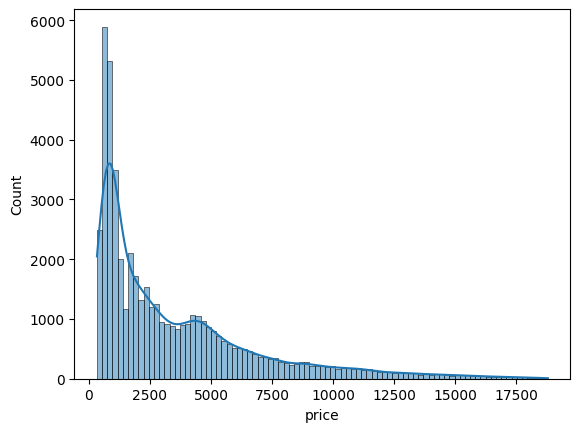

In [5]:
# histogram to see the distribution of target variable
sns.histplot(data=df, x="price", kde=True)

<b>Let's remove even more from the high end</b>

In [6]:
# after outlier removal
# mean 472265
# deviation 207983
df.describe()

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
count,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,...,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000
mean,0.743245,61.742480,57.377092,3501.810940,5.626000,5.629811,3.474251,0.255879,0.221396,0.086802,...,0.148489,0.094764,0.042738,0.069317,0.096989,0.155241,0.229085,0.246902,0.160139,0.007455
std,0.402708,1.333521,2.145475,3402.104964,1.027023,1.026294,0.647084,0.436358,0.415191,0.281548,...,0.355587,0.292892,0.202267,0.253995,0.295945,0.362138,0.420248,0.431213,0.366738,0.086019
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.390000,61.100000,56.000000,921.000000,4.680000,4.690000,2.890000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.700000,61.800000,57.000000,2260.000000,5.640000,5.640000,3.480000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.020000,62.500000,59.000000,4899.000000,6.460000,6.460000,4.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.650000,72.900000,73.000000,18806.000000,8.990000,31.800000,31.800000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# variation is a bit high for easy comparison
# 43 256 936 526 (43 billion etc.)
df.var()

carat            1.621736e-01
depth            1.778278e+00
table            4.603062e+00
price            1.157432e+07
x                1.054775e+00
y                1.053280e+00
z                4.187181e-01
cut_Premium      1.904086e-01
cut_Very Good    1.723832e-01
cut_Good         7.926904e-02
cut_Fair         2.098727e-02
color_E          1.517596e-01
color_F          1.476811e-01
color_G          1.691311e-01
color_H          1.264422e-01
color_I          8.578559e-02
color_J          4.091185e-02
clarity_VVS1     6.451323e-02
clarity_VVS2     8.758373e-02
clarity_VS1      1.311436e-01
clarity_VS2      1.766085e-01
clarity_SI1      1.859450e-01
clarity_SI2      1.344971e-01
clarity_I1       7.399249e-03
dtype: float64

In [8]:
# ALSO CHECK CORRELATION MATRIX BEFORE UNDERSAMPLING
df.corr()

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
carat,1.000000,0.016279,0.163165,0.913312,0.981726,0.974653,0.958619,0.125715,-0.004794,0.015497,...,0.079947,0.139300,0.107064,-0.172303,-0.132079,-0.046622,-0.035667,0.098949,0.240254,0.055993
depth,0.016279,1.000000,-0.286487,-0.010538,-0.034720,-0.036860,0.083849,-0.205930,0.037016,0.171453,...,0.023527,0.026288,0.024301,-0.019387,-0.018649,-0.017665,-0.002454,0.050742,0.005507,0.000285
table,0.163165,-0.286487,1.000000,0.100585,0.175850,0.168145,0.134064,0.370853,0.131836,0.166501,...,0.007728,0.004032,0.015244,-0.072724,-0.061180,-0.025762,-0.009733,0.063072,0.095387,0.023333
price,0.913312,-0.010538,0.100585,1.000000,0.875079,0.870803,0.852788,0.096989,-0.018302,-0.023294,...,0.027776,0.059614,0.009622,-0.089900,-0.034353,0.009579,0.000017,0.024008,0.074388,-0.015272
x,0.981726,-0.034720,0.175850,0.875079,1.000000,0.991526,0.969637,0.132010,-0.008098,0.013520,...,0.075367,0.123596,0.104455,-0.185574,-0.141101,-0.045772,-0.033272,0.106997,0.246954,0.061278
y,0.974653,-0.036860,0.168145,0.870803,0.991526,1.000000,0.964148,0.111703,0.005227,0.016570,...,0.073116,0.123360,0.104097,-0.182819,-0.137925,-0.043024,-0.034616,0.105216,0.242525,0.058225
z,0.958619,0.083849,0.134064,0.852788,0.969637,0.964148,1.000000,0.093872,0.005216,0.033972,...,0.075046,0.123572,0.105157,-0.182233,-0.138780,-0.043694,-0.033390,0.109400,0.239059,0.055689
cut_Premium,0.125715,-0.205930,0.370853,0.096989,0.132010,0.111703,0.093872,1.000000,-0.312696,-0.180792,...,0.026037,0.006177,0.009204,-0.054387,-0.063125,-0.012290,0.022054,0.021948,0.070761,0.029248
cut_Very Good,-0.004794,0.037016,0.131836,-0.018302,-0.008098,0.005227,0.005216,-0.312696,1.000000,-0.164403,...,-0.004045,-0.004509,0.006307,-0.010067,0.015987,-0.007295,-0.019793,0.034433,0.004899,-0.021624
cut_Good,0.015497,0.171453,0.166501,-0.023294,0.013520,0.016570,0.033972,-0.180792,-0.164403,1.000000,...,-0.009645,-0.001068,0.009905,-0.038293,-0.038506,-0.013879,-0.023581,0.062172,0.040012,0.004707


In [9]:
outliers

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
2,0.23,56.9,65.0,327,4.05,4.07,2.31,0,0,1,...,0,0,0,0,0,1,0,0,0,0
91,0.86,55.1,69.0,2757,6.45,6.33,3.52,0,0,0,...,0,0,0,0,0,0,0,0,1,0
172,1.17,60.2,61.0,2774,6.83,6.90,4.13,0,1,0,...,0,0,1,0,0,0,0,0,0,1
241,1.01,64.5,58.0,2788,6.29,6.21,4.03,0,0,0,...,0,0,0,0,0,0,0,0,0,1
356,0.57,58.7,66.0,2805,5.34,5.43,3.16,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53542,0.78,54.7,67.0,2691,6.25,6.15,3.40,0,0,0,...,1,0,0,0,0,0,1,0,0,0
53649,1.05,59.6,63.0,2705,6.61,6.55,3.92,0,1,0,...,0,0,1,0,0,0,0,0,0,1
53660,0.71,57.3,67.0,2707,5.96,5.76,3.36,0,0,0,...,0,0,0,0,0,1,0,0,0,0
53697,0.70,64.5,65.0,2717,5.52,5.45,3.54,0,0,0,...,1,0,0,0,1,0,0,0,0,0


In [10]:
df

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,1,0,0,...,0,1,0,0,0,0,1,0,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,0,0,1,...,0,0,1,0,0,0,0,0,1,0
5,0.24,62.8,57.0,336,3.94,3.96,2.48,0,1,0,...,0,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,0,0,0,...,0,0,0,0,0,0,0,1,0,0
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,0,0,1,...,0,0,0,0,0,0,0,1,0,0
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,0,1,0,...,0,0,0,0,0,0,0,1,0,0
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,1,0,0,...,1,0,0,0,0,0,0,0,1,0


<b>After outlier removal, we'll see the current distribution</b>

<Axes: xlabel='price', ylabel='Count'>

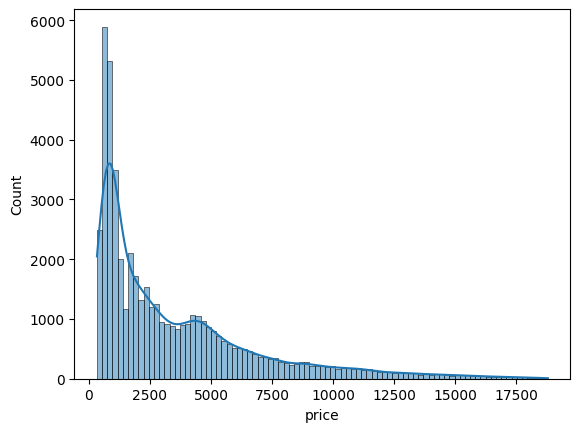

In [11]:
sns.histplot(data=df, x="price", kde=True)

In [12]:
df

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,1,0,0,...,0,1,0,0,0,0,1,0,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,0,0,1,...,0,0,1,0,0,0,0,0,1,0
5,0.24,62.8,57.0,336,3.94,3.96,2.48,0,1,0,...,0,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,0,0,0,...,0,0,0,0,0,0,0,1,0,0
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,0,0,1,...,0,0,0,0,0,0,0,1,0,0
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,0,1,0,...,0,0,0,0,0,0,0,1,0,0
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,1,0,0,...,1,0,0,0,0,0,0,0,1,0


<b>Undersampling for regression - we need to create a temporary CATEGORICAL variable on TARGET REGRESSION VARIABLE</b>

<b>Finally, compare the statistics in order to see if the dataset still is close to original in its representation</b>

<b>Since we altered the target distribution heavily, we can expect basic statistics like mean, median, standard deviation and variation to change.</b>
<p>
However, correlations regarding the price-variable seem to be 99% the same! (which is promising). A good idea would also to check the phik-matrix before and after undersampling.
</p>

**TEST ML WITH THIS**

In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import seaborn as sns
import xgboost as xgb


In [14]:
# X/y 
X = df.drop("price", axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# model1 = xgb.XGBRegressor(objective='reg:squarederror')
model1 = LinearRegression()
model1.fit(X_train, y_train)
predictions = model1.predict(X_test)

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, predictions), 2))



RMSE:
1010.87 $

R-squared:
0.91


In [15]:
df.head()

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,1,0,0,...,0,1,0,0,0,0,1,0,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,0,0,1,...,0,0,1,0,0,0,0,0,1,0
5,0.24,62.8,57.0,336,3.94,3.96,2.48,0,1,0,...,0,0,1,0,1,0,0,0,0,0


In [16]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

# 1. Split features and target
X = df.drop("price", axis=1)
y = df['price'].values.reshape(-1, 1)  # reshape needed for PowerTransformer

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale features
x_scaler = MinMaxScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# 4. Initialize PowerTransformer with Yeo-Johnson
y_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
y_train_trans = y_transformer.fit_transform(y_train)

# 5. Transform test target (optional, just for reference)
y_test_trans = y_transformer.transform(y_test)

# 6. Train model on transformed target
model = LinearRegression()
model.fit(X_train_scaled, y_train_trans.ravel())

# 7. Predict on test set (transformed space)
predictions_trans = model.predict(X_test_scaled)

# 8. Inverse transform predictions back to original scale
predictions = y_transformer.inverse_transform(predictions_trans.reshape(-1, 1)).ravel()

# 9. Evaluate on original scale
rmse = np.sqrt(metrics.mean_squared_error(y_test.ravel(), predictions))
r2 = metrics.r2_score(y_test.ravel(), predictions)

print('\nRMSE:')
print(round(rmse, 2), "$")

print('\nR-squared:')
print(round(r2, 2))



RMSE:
957.06 $

R-squared:
0.92


In [17]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from scipy.stats import boxcox
from scipy.special import inv_boxcox

X = df.drop("price", axis=1)
y = df['price']

# Check for non-positive targets
if (y <= 0).any():
    raise ValueError("Box-Cox requires strictly positive target values.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

x_scaler = MinMaxScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# Box-Cox transform only training target
y_train_bc, fitted_lambda = boxcox(y_train)

model = LinearRegression()
model.fit(X_train_scaled, y_train_bc)

# Predict in transformed space
predictions_bc = model.predict(X_test_scaled)

# Inverse transform predictions back to original scale
predictions = inv_boxcox(predictions_bc, fitted_lambda)

# Calculate metrics on original target scale (no need to transform y_test)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r2 = metrics.r2_score(y_test, predictions)

print('\nRMSE:')
print(round(rmse, 2), "$")

print('\nR-squared:')
print(round(r2, 2))



RMSE:
956.51 $

R-squared:
0.92


In [18]:
import numpy as np

# Log-transform the target
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# Train model on log-transformed target
model = LinearRegression()
model.fit(X_train_scaled, y_train_log)

# Predict on test set (log space)
predictions_log = model.predict(X_test_scaled)

# Inverse transform predictions back to original scale
predictions = np.exp(predictions_log)

# Evaluate on original scale
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r2 = metrics.r2_score(y_test, predictions)

print('\nRMSE (log transform):')
print(round(rmse, 2), "$")

print('\nR-squared (log transform):')
print(round(r2, 2))



RMSE (log transform):
905.62 $

R-squared (log transform):
0.93
